# HI 21-cm Analysis (Lab 2 Part 3): Final HI Profile Extraction

This notebook is the **third and final stage** of a three-part investigation:

1. **Part 1 (`equipment_calibration.ipynb`)**: characterize signal-chain attenuation, passband shape, and linear regime.
2. **Part 2 (`temperature_calibration.ipynb`)**: establish receiver/noise-temperature scale and export calibration contracts.
3. **Part 3 (this notebook)**: extract the HI profile with kinematic and intensity analysis, uncertainty accounting, and requirement-level traceability.

The analysis is intentionally dual-path:

- **Path A (ratio-domain)** for robust line-shape/kinematics.
- **Path B (temperature-domain)** for calibrated line intensity with hardware-aware systematics.

Final science statements are accepted only when both paths are consistent within reported uncertainties.

## Requirement Traceability Matrix (Lab Handouts → This Notebook)

| Source | Requirement / Theory Clause | Implementation in This Notebook |
|---|---|---|
| `bighorn.tex` §Analysis Week 1 | Combine spectra; compare mean vs median; smooth without erasing <1 km/s structure | Mean/median comparison + explicit smoothing-policy derivation and limit check |
| `bighorn.tex` §Analysis Week 1 | Build line-shape ratio \(s_{on}/s_{off}\) | Path A ratio-domain construction (\(R-1\), \(1/R-1\)) |
| `bighorn.tex` §Get Line Intensity | Convert to temperature scale using calibration spectra | Path B temperature mapping using `calibration_results_v2.npz` (latest contract) |
| `bighorn.tex` §Velocity + LSR | Plot in velocity and apply LSR correction | Radio Doppler axis + `ugradio.doppler.get_projected_velocity` per-spectrum correction |
| `bighorn.tex` Week 2 | Baseline removal + multi-Gaussian decomposition + fit quality | Constrained Gaussian+polynomial model grid, AICc/\(\chi_r^2\), baseline sensitivity tests |
| `cal_intensity.tex` | Naive vs cool calibration logic; product/ratio error propagation | Implemented cool-method-compatible scaling and first-order propagated uncertainties |
| `coords.tex` | Rotation-matrix coordinate chain and verification | Explicit J2000 matrix chain `(l,b)->(ra,dec)->(HA,Dec)->(Az,Alt)` + astropy/ugradio cross-check |
| `horn_signal_chain_test.tex` | Operate in linear regime; verify gain/frequency-chain sanity | Artifact-based clipping/headroom checks and linearity diagnostics before science fits |


## Implemented Theory (Handout-Aligned)

### 1) Backend radiometry model


a radiometric channel is modeled as

$$
P_j = G_j \, T_{\mathrm{sys}}(\nu_j),
$$

with

$$
T_{\mathrm{sys}}(\nu)=T_{\mathrm{rcvr}}+T_{\mathrm{ant,cont}}+T_{\mathrm{ant,HI}}(\nu)
$$

(`cal_intensity.tex`, `bighorn.tex`).

### 2) Frequency-switched ratio line-shape extraction

Using paired LO settings,

$$
R(\nu)=\frac{P_{1420}(\nu)}{P_{1421}(\nu)},\qquad y_R=R-1,
$$
$$
R^{-1}(\nu)=\frac{P_{1421}(\nu)}{P_{1420}(\nu)},\qquad y_{\mathrm{inv}}=\frac{1}{R}-1.
$$

This corresponds to the handout line-shape ratio step (bandpass division) in unitless form.

### 3) Intensity calibration and cool-method connection

Handout intensity scaling (`bighorn.tex`) is

$$
G_{\mathrm{scale}}=
\frac{T_{\mathrm{sys,cal}}-T_{\mathrm{sys,cold}}}{\sum_j (s_{\mathrm{cal},j}-s_{\mathrm{cold},j})}
\sum_j s_{\mathrm{cold},j},
$$

with calibrated line estimate

$$
T_{\mathrm{line}} = r_{\mathrm{line}}\, G_{\mathrm{scale}}.
$$

`cal_intensity.tex` shows the lower-noise cool-method decomposition: ratio gives **shape**, channel-averaged calibration gives **scale**. In this notebook, that appears as

$$
T_{\mathrm{sys,ref}}(\nu)=P_{\mathrm{ref}}(\nu)
\frac{T_{\mathrm{cold}}+T_{\mathrm{rx}}}{P_{\mathrm{cold,ref}}(\nu)},
$$
$$
T_{\mathrm{line},R}=(R-1)\,T_{\mathrm{sys,ref}},
$$
$$
T_{\mathrm{line},\mathrm{inv}}=-\frac{y_{\mathrm{inv}}}{1+y_{\mathrm{inv}}}\,T_{\mathrm{sys,ref}}.
$$

### 4) Velocity axis and LSR frame

Radio velocity convention:

$$
v_{\mathrm{radio}} = c\,\frac{\nu_0-\nu}{\nu_0}.
$$

Frame correction:

$$
v_{\mathrm{LSR}} = v_{\mathrm{topo}} + \Delta v_{\mathrm{LSR}},
$$

where \(\Delta v_{\mathrm{LSR}}\) is computed with `ugradio.doppler.get_projected_velocity` from observation time, site, and pointing metadata.

### 5) Baseline + Gaussian decomposition model

$$
y(v)=\sum_{k=1}^{N} A_k\exp\!\left[-\frac{(v-\mu_k)^2}{2\sigma_k^2}\right] + \sum_{m=0}^{M} c_m (v/100)^m.
$$

Off-line channels are used only to seed the polynomial coefficients; the final optimizer re-fits the Gaussian components and baseline simultaneously over the full fit window.
Model grid search reports \(\chi_r^2\), AICc, and physical-width compliance; baseline-order perturbations compare alternate joint Gaussian+baseline fits to estimate a baseline-model systematic term.

### 6) Uncertainty propagation

Product/ratio propagation follows first-order Taylor form (`cal_intensity.tex`):

$$
\left(\frac{\sigma_q}{q}\right)^2 = \sum_i \left(\frac{\partial \ln q}{\partial x_i}\sigma_{x_i}\right)^2,
$$

with terms for ratio statistics, temperature-calibration uncertainty, and hardware systematic fraction.

## Step 1 - Setup constants, policies, and file contracts

- Enforce calibration-contract ingestion from Parts 1 and 2.
- Keep Path A and Path B parity.
- Use a fixed smoothing policy constrained by the 1 km/s handout requirement.
- Use deterministic constrained model selection with reproducible caches.

In [1]:
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Markdown, display

LAB02_DIR = Path.cwd().resolve()
if not (LAB02_DIR / "utils").exists():
    LAB02_DIR = (Path.cwd() / "labs" / "02").resolve()
if str(LAB02_DIR) not in sys.path:
    sys.path.insert(0, str(LAB02_DIR))

pd.options.display.max_columns = 200
pd.options.display.float_format = "{:.4f}".format

from utils import run_analysis
from utils.plotting import figure
from utils.tables import table

/Users/junruiting/GitHub/ay-121/.venv/lib/python3.14/site-packages/rtlsdr/__init__.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## Step 2 - Helper operators (I/O, interpolation, masking, smoothing, fitting)

## Step 3 - Load dual-LO datasets and validate calibration artifacts from Parts 1 and 2

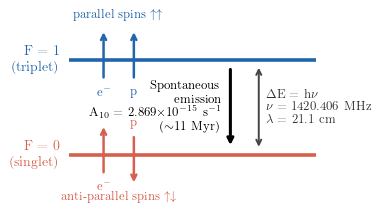

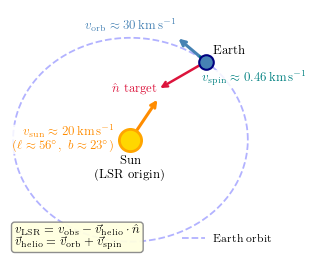

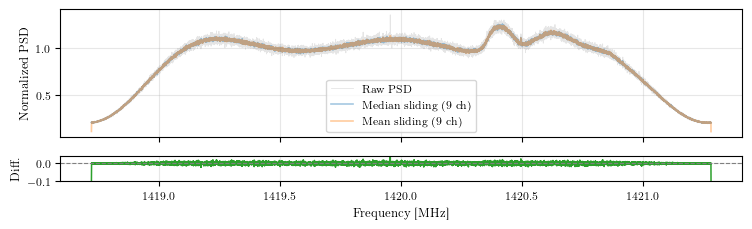

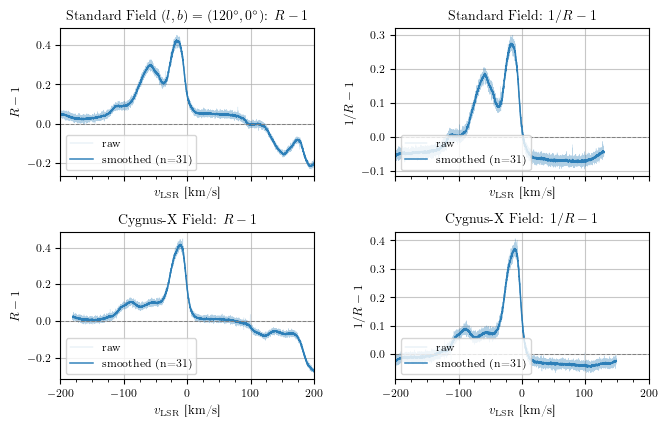

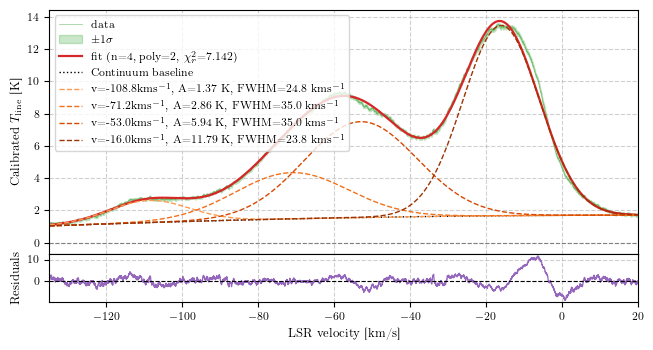

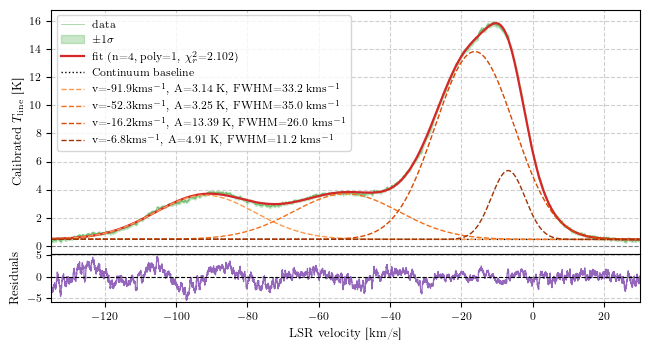

Part 3 produced `8` tables and `6` figures.

In [2]:
analysis = run_analysis()
display(Markdown(
    f"Part 3 produced `{len(analysis.tables)}` tables and `{len(analysis.figures)}` figures."
))

## Step 4 - Signal-Chain Linearity and Headroom Sanity (from `horn_signal_chain_test.tex` expectations)

Before science extraction, verify the analysis is anchored to linear operating conditions:

- compare target ADC-scale input (100 mVpp reference from handout memo) to measured unclipped/clipped setpoints,
- report clipping margin,
- carry forward linearity residual as part of systematic budget.

In [3]:
display(table(analysis, "linearity_headroom"))

,target_100mVpp_dbm,highest_unclipped_setpoint_dbm,first_clipped_setpoint_dbm,linearity_rmse_db
0,-16.0206,13.0000,15.5000,0.0979


## Step 5 - Physical Context for 21-cm Line Interpretation

## 21-cm Hyperfine Transition

The 21-cm line arises from the spin-flip transition in the ground state of neutral hydrogen (HI). The ground state hyperfine structure is split by the magnetic interaction between the proton's nuclear spin and the electron's spin:

- **F = 1 (triplet)**: electron and proton spins *parallel* (higher energy)
- **F = 0 (singlet)**: electron and proton spins *anti-parallel* (lower energy)

The energy difference corresponds to a photon frequency of **ν = 1420.40575 MHz** (λ = 21.1 cm).

**Spontaneous emission coefficient**: A₁₀ = 2.869 × 10⁻¹⁵ s⁻¹, giving a mean lifetime of ~11 million years. Despite this extremely slow rate, the 21-cm line is detectable because:
1. The ISM contains enormous column densities of neutral hydrogen (N_HI ~ 10²⁰–10²² cm⁻²)
2. The Galaxy is optically thin at 21 cm along most lines of sight
3. Radio receivers can detect very faint signals

**Rayleigh-Jeans approximation**: At 1420 MHz, hν/k_B ≈ 0.068 K ≪ T_spin (typically 50–8000 K), so the Rayleigh-Jeans law applies: B_ν ∝ T. This means measured antenna temperatures directly trace the spin temperature of the HI gas.


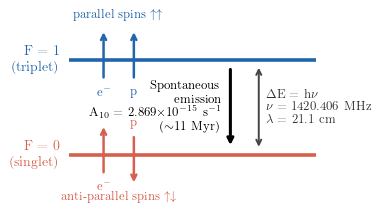

In [4]:
display(figure(analysis, "hyperfine"))

## Line Broadening Mechanisms

The 21-cm line profile is broadened by several physical mechanisms, each encoding different ISM physics:

### 1. Thermal Broadening (dominant for individual components)
From the Maxwell-Boltzmann velocity distribution, the 1D velocity dispersion is:
$$\sigma_{\mathrm{th}} = \sqrt{\frac{k_B T}{m_H}}$$
The line FWHM is related by FWHM = 2.355 $\sigma_{\mathrm{th}}$ (for a Gaussian profile).

| ISM Phase | T [K] | $\sigma_{\mathrm{th}}$ [km/s] | FWHM$_{\mathrm{th}}$ [km/s] |
|-----------|--------|-------------------------------|-------------------------------|
| Cold Neutral Medium (CNM) | 50–100 | 0.6–0.9 | 1.4–2.1 |
| Lukewarm Neutral | ~1000 | 2.9 | 6.8 |
| Warm Neutral Medium (WNM) | 5000–8000 | 6.4–8.2 | 15–19 |

### 2. Turbulent Broadening
ISM turbulence adds a non-thermal component $\sigma_{\mathrm{turb}} \sim 1\text{–}10$ km/s depending on environment. The total line width becomes $\sigma^2 = \sigma_{\mathrm{th}}^2 + \sigma_{\mathrm{turb}}^2$.

### 3. Instrumental & Beam Broadening
- **Spectral resolution**: native channel width is ~78.1 Hz (≈0.0165 km/s at 21 cm). Practical resolution is set by the chosen smoothing kernel, kept below the 1 km/s handout bound.
- **Beam smearing**: the 9m dish has ~5° HPBW at 1420 MHz, averaging over spatial structure.

### Interpretation and Model Choices
Narrow components (FWHM < 5 km/s) trace **CNM**, while broad components (FWHM > 15 km/s) trace **WNM**. Heiles & Troland (2003, ApJ 586, 1067) used multi-Gaussian decompositions with 2–4 components to isolate these phases, and we adopt the same 2–4 component grid to keep our fits comparable while avoiding overfitting. Note this citation in your formal report to justify the Gaussian count and width ranges.


## Step 6 - Coordinate Transformation Chain

To observe a target and correct for Doppler shifts, we must transform through a series of coordinate systems:

**1. Galactic (ℓ, b) → Equatorial (RA, Dec)**
The fixed J2000 rotation matrix converts between Galactic and equatorial frames:
$$\begin{pmatrix} x_{eq} \\ y_{eq} \\ z_{eq} \end{pmatrix} = R_{gal\to eq}^{2000} \begin{pmatrix} x_{gal} \\ y_{gal} \\ z_{gal} \end{pmatrix}$$
This matrix is *fixed* (doesn't depend on time or observer location).

**2. Equatorial (RA, Dec) → Hour Angle (HA, Dec)**
$$\text{HA} = \text{LST} - \text{RA}$$
This step is *time-dependent*: LST (Local Sidereal Time) changes as Earth rotates.

**3. Hour Angle → Horizontal (Az, Alt)**
The final rotation uses observer latitude φ and HA:
$$\sin(\text{Alt}) = \sin(\delta)\sin(\phi) + \cos(\delta)\cos(\phi)\cos(\text{HA})$$
$$\cos(\text{Az})\cos(\text{Alt}) = \cos(\delta)\sin(\phi) - \sin(\delta)\cos(\phi)\cos(\text{HA})$$

**Why this chain matters for our observations:**
- **Galactic coordinates** are natural for ISM science (arm structure, latitude above midplane)
- **Equatorial coordinates** are needed for catalog cross-matching (HI4PI survey, source catalogs)
- **Horizontal coordinates** are what the telescope physically points to
- **LSR correction** requires knowing the 3D velocity of the observer, which depends on the equatorial/ecliptic frame

**Note on numerical precision.** Small discrepancies (sub-km/s level) between coordinate implementations (e.g., `ugradio.coord` vs `astropy`) are expected and arise from floating-point accumulation across the matrix chain and from differing precession models. These differences are at the level of numerical accuracy and do not affect scientific conclusions.


In [5]:
display(table(analysis, "coordinate_check"))

,ra_deg,dec_deg,ha_deg,alt_deg,az_deg
0,6.4508,62.7257,353.9607,64.8752,6.5201


## Coordinate Frame Rotation Chain: (ℓ, b) → (α, δ) → (HA, δ) → (Az, Alt)

Per `coords.tex`, we use the explicit J2000 matrix
\(R_{(\alpha,\delta)_{2000} \rightarrow (\ell,b)}\) and apply its transpose for galactic-to-equatorial conversion.
This avoids ambiguity from reconstructing basis vectors from rounded anchor constants.

The matrix used in code is:

\[
R_{(\alpha,\delta)_{2000} \rightarrow (\ell,b)}=
\begin{bmatrix}
-0.054876 & -0.873437 & -0.483835\\
\phantom{-}0.494109 & -0.444830 & \phantom{-}0.746982\\
-0.867666 & -0.198076 & \phantom{-}0.455984
\end{bmatrix}.
\]

**Full chain for target direction (ℓ, b) = (120°, 0°):**

1. **(ℓ, b) → (α, δ):** `xyz_eq = M_gal2eq @ [cos(b)cos(ℓ), cos(b)sin(ℓ), sin(b)]`; recover α, δ.
2. **(α, δ) → (HA, δ):** `HA = LST − α` using the observation LST metadata.
3. **(HA, δ) → (Az, Alt):** standard spherical trig, `sin(Alt)=sin(δ)sin(φ)+cos(δ)cos(φ)cos(HA)`.

Result is verified against both `ugradio.coord.get_altaz` and `astropy.coordinates` transforms.

This chain is explicitly used for the Week-2 target \((l,b)=(120^\circ,0^\circ)\) and compared to `astropy`/`ugradio.coord` for sign-convention validation.

## Step 7 - LSR Velocity Correction

Observed radial velocities are corrected from topocentric frame to the Local Standard of Rest (LSR):

$$v_{LSR} = v_{topo} + \Delta v_{LSR}.$$ 

In this notebook, $\Delta v_{LSR}$ is computed by `ugradio.doppler.get_projected_velocity` inside `lsr_correction_kms(spectrum)`, using:

- observation JD,
- observatory coordinates,
- pointing metadata (preferred: Az/Alt -> ICRS `(ra, dec)`),
- zenith fallback only if pointing metadata are missing.

This satisfies the handout requirement to compare observing-frame and LSR-frame spectra on a reproducible reference frame.

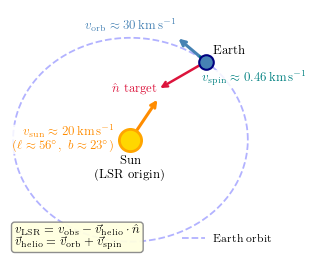

In [6]:
display(figure(analysis, "lsr_geometry"))

## Step 8 - Mean/Median Combination and Smoothing Policy (Week-1 Analysis Requirement)

To keep the smoothing-policy discussion focused on the kernel itself (not on LO switching), we analyze one representative `-0` observation near 1420 MHz. The smoothing kernel averages the center bin plus eight neighbors, so the effective width stays within the 1 km/s handout constraint while highlighting how mean smoothing preserves the narrow line and the median suppresses transients.

- Only the `-0` trace is shown to mirror the handout's emphasis on smoothing behavior, not on combining multiple pointings.
- The horizontal axis is the true RF frequency (no 1.42 GHz offset), and no LO labels appear on the figure.
- RFI-screened PSD diagnostics come from `temperature_calibration.ipynb`; this comparison simply contrasts how mean and median slide filters react within the same masked band.


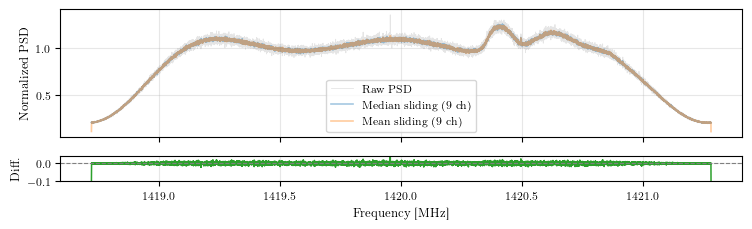

In [7]:
display(figure(analysis, "mean_vs_median"))

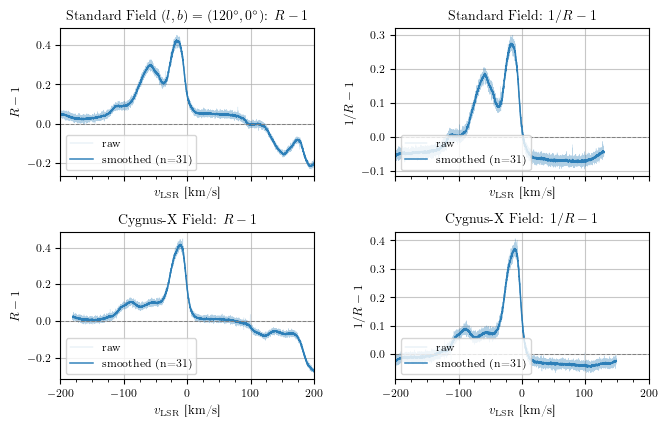

In [8]:
display(figure(analysis, "ratio_profile"))

## Step 9 - FIR/Band-Edge and Aliasing Placement Check

`bighorn.tex` asks whether FIR response approaches zero at band edges and what that implies for aliasing and line placement.

This check uses `equipment_calibration_results_v2.npz` response/mask products to ensure the analysis windows sit in the stable passband/evaluation region.

## Step 9b - Radiometer-Equation Thermal Noise Sanity

## Step 10 - Path A: Ratio-Domain Line Shape and Kinematic Fits

This path implements the handout line-shape ratio concept directly in PSD space:

- construct \(R-1\) and \(1/R-1\),
- apply fixed smoothing policy,
- fit joint Gaussian+polynomial baseline models for kinematic inference.

In [9]:
for name, frame in table(analysis, "ratio_model_tables").items():
    display(Markdown(f"### {name}"))
    display(frame)

### standard:R

,n_gauss,poly_order,chi2_red,aic,aicc,bic,n_phys_viol,status,selected
0,2,1,113.3451,1064553.4176,1064553.4329,1064610.6053,0,ok,False
1,2,2,22.8202,214322.7476,214322.7668,214387.0838,0,ok,False
2,3,1,29.3473,275563.8672,275563.8953,275642.5003,0,ok,False
3,3,2,15.3761,144374.9104,144374.9436,144460.6919,0,ok,False
4,4,1,12.0788,113399.6285,113399.6732,113499.7070,0,ok,False
5,4,2,11.8889,111607.1792,111607.2304,111714.4062,0,ok,True


### standard:Rinv

,n_gauss,poly_order,chi2_red,aic,aicc,bic,n_phys_viol,status,selected
0,2,1,110.2051,1035062.1511,1035062.1664,1035119.3388,0,ok,False
1,2,2,472.3755,4436096.6989,4436096.7181,4436161.0351,0,ok,False
2,3,1,30.0898,282535.0120,282535.0401,282613.6451,0,ok,False
3,3,2,16.0872,151050.9999,151051.0332,151136.7815,0,ok,False
4,4,1,12.7599,119792.7567,119792.8015,119892.8352,0,ok,False
5,4,2,12.6042,118320.6997,118320.7509,118427.9267,0,ok,True


### cygnus-x:R

,n_gauss,poly_order,chi2_red,aic,aicc,bic,n_phys_viol,status,selected
0,2,1,388.2091,3881718.4161,3881718.4305,3881776.1045,0,ok,False
1,2,2,79.4539,794398.0166,794398.0346,794462.9159,0,ok,False
2,3,1,57.5171,574963.2708,574963.2972,575042.5922,0,ok,False
3,3,2,57.1206,570944.1911,570944.2223,571030.7236,0,ok,False
4,4,1,2.4776,24786.1884,24786.2304,24887.1429,0,ok,False
5,4,2,2.3493,23504.1376,23504.1856,23612.3032,0,ok,True


### cygnus-x:Rinv

,n_gauss,poly_order,chi2_red,aic,aicc,bic,n_phys_viol,status,selected
0,2,1,385.7138,3856768.5021,3856768.5165,3856826.1904,0,ok,False
1,2,2,78.5433,785294.1657,785294.1837,785359.0651,0,ok,False
2,3,1,56.4088,563884.4854,563884.5118,563963.8068,0,ok,False
3,3,2,56.8185,567925.2129,567925.2442,568011.7454,0,ok,False
4,4,1,2.8104,28112.6957,28112.7377,28213.6503,0,ok,False
5,4,2,2.7552,27559.7869,27559.8349,27667.9525,0,ok,True


## Analysis / Discussion / Method: Why We Enforce Physical Fits

Our Gaussian decomposition is not only a numerical smoothing tool; it is intended to represent physically interpretable HI velocity components.
Without physical constraints, least-squares can improve residuals by creating components that absorb baseline ripple, calibration mismatch, or branch-specific artifacts rather than real gas structure.
Production fits in this notebook are joint fits: a low-order polynomial baseline and all Gaussian components are optimized simultaneously, rather than subtracting a frozen baseline before the science fit.

### 1) Thermal and non-thermal line-width physics

For neutral hydrogen, thermal Doppler broadening gives
$$
\sigma_{\mathrm{th}}=\sqrt{\frac{k_B T}{m_H}}, \qquad \mathrm{FWHM}=2.355\,\sigma.
$$
A useful HI conversion is
$$
T_{\mathrm{thermal}}[\mathrm{K}] \approx 21.8\left(\frac{\mathrm{FWHM}}{\mathrm{km\,s^{-1}}}\right)^2.
$$
So very broad single components imply very high kinetic temperatures if interpreted as purely thermal.
In reality, observed width combines thermal and non-thermal terms:
$$
\sigma_{\mathrm{obs}}^2 \approx \sigma_{\mathrm{th}}^2 + \sigma_{\mathrm{turb}}^2 + \sigma_{\mathrm{instr}}^2.
$$
This means broad components can occur, but they should still remain in a physically credible regime for neutral gas and instrument response.

### 2) Why constraints are needed in this notebook

Three practical failure modes motivate constrained fitting:
1. **Over-flexible mixtures**: too many Gaussians can fit noise or baseline structure.
2. **Unphysical widths**: very broad/narrow components can minimize residuals but lose ISM meaning.
3. **Branch asymmetry** (`R` vs `Rinv`): inverse-branch systematics can bias unconstrained model selection.

### 3) Operational policy used here

To keep fits interpretable, we enforce:
- bounded component widths (physics-informed $\sigma$/FWHM range used as hard optimizer bounds),
- a soft interior edge penalty that discourages solutions from hugging those physical bounds,
- model selection that first prefers statistically acceptable fits ($\chi^2_\nu$ in range), then lower AICc,
- explicit `selected` markers in model tables for transparency.

### 4) Interpretation guidance

- Components satisfying both goodness-of-fit and width constraints are treated as physically interpretable candidates.
- Components driven to the physical-width boundaries are treated as caution flags for possible model-compensation terms (baseline/calibration/systematics), not strong standalone detections.
- `Rinv` results are used as consistency/systematics diagnostics; physically trusted inference is anchored to the stable constrained solutions.


Baseline guidance crosswalk: handout offline windows ±(0.6-1.2) MHz correspond to roughly ±(126.7-253.4) km/s around 1420.40575 MHz; the production policy uses the available overlap region to seed the polynomial and to define baseline-model systematic tests while preserving this scale.

## Step 13 - Baseline-Removal Systematic (Polynomial Order Perturbation)

In [10]:
display(table(analysis, "baseline_systematics"))

,dataset,profile,poly_best,n_gauss,sys_centroid_kms,sys_fwhm_kms
0,standard,R,2,4,10.4098,13.7033
1,standard,Rinv,2,4,10.8422,13.5419
2,cygnus-x,R,2,4,26.2876,10.9386
3,cygnus-x,Rinv,2,4,2.1672,1.2094


## Step 14 - Shared-Fit Visualization and Cross-Path Agreement Tests

### Standard Fits

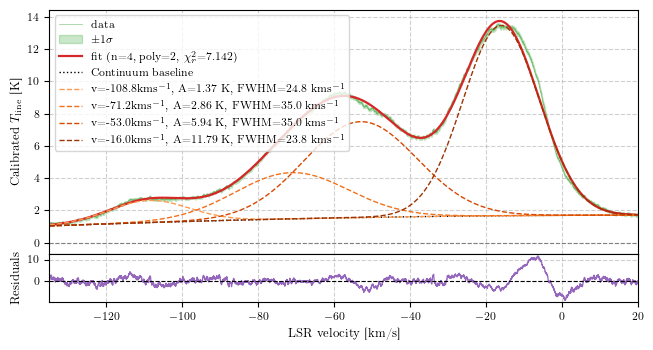

### Cygnus-X Fits

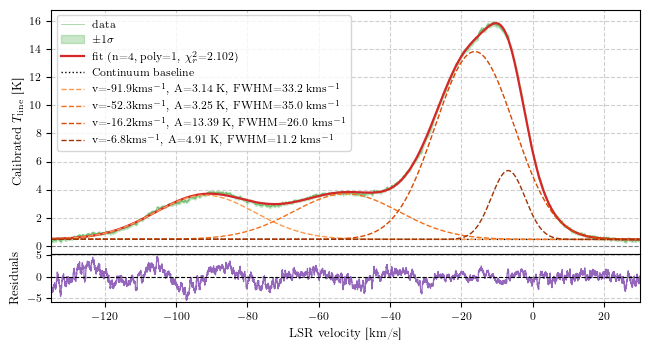

In [11]:
for name in ["standard_fits", "cygnus-x_fits"]:
    display(Markdown(f"### {name.replace('_', ' ').title()}"))
    display(figure(analysis, name))

## Step 15 - Final Reporting Blocks and Calibration-Link Check

In [12]:
for name in ["summary", "eta_efficiency"]:
    display(Markdown(f"### {name.replace('_', ' ').title()}"))
    display(table(analysis, name))

display(Markdown("### Component Tables"))
for label, frame in table(analysis, "component_tables").items():
    display(Markdown(f"#### {label}"))
    display(frame)

display(Markdown("### Calibrated-Path Fit Tables"))
for label, frame in table(analysis, "temp_model_tables").items():
    display(Markdown(f"#### {label}"))
    display(frame)

### Summary

,dataset,profile,n_gauss,poly_order,chi2_red,centroid,sigma_centroid,fwhm_eff,sigma_fwhm_eff,area,sigma_area,residual_rms
0,Cygnus-X,R,4,1,2.1015,-34.7122,0.0625,74.8533,0.1154,660.3841,1.1267,1.4480
1,"HI profile at (l=120°, b=0°)",R,4,2,7.1421,-42.3093,4.8800,70.1292,4.7215,662.6505,124.8948,2.6665


### Eta Efficiency

,trx_1420_k,sigma_trx_1420_k,tcold_k,baseline_offline_k,line_peak_est_k_q95,line_noise_offline_k_mad,line_sigma_total_k,tb_ref_line_k,tb_ref_line_sigma_k,eta_eff,eta_eff_sigma,eta_eff_ci95_lo,eta_eff_ci95_hi,assumptions
0,79.33348255022386,27.98813489309245,30.0,-79.2477221353738,0.05370761533503624,0.003622596381011196,27.988141961922672,80.0,30.0,0.000671345191687953,0.34985186510567107,-0.6850383104154273,0.6863810007988033,eta_eff = eta_ap*eta_bf; standard-field LO1420...


### Component Tables

...

,n_gauss,poly_order,chi2_red,aic,aicc,bic,n_phys_viol,status,selected
0,2,1,4165.5667,39123018.2090,39123018.2243,39123075.3967,0,ok,False
1,2,2,114.4646,1074955.4708,1074955.4899,1075019.8069,0,ok,False
2,3,1,37.4793,351915.0075,351915.0356,351993.6406,0,ok,False
3,3,2,36.2474,340314.6115,340314.6447,340400.3930,0,ok,False
4,4,1,30.1759,283258.5621,283258.6069,283358.6406,0,ok,False
5,4,2,6.1392,57646.0941,57646.1452,57753.3210,0,ok,True


#### cygnus-x:R

,n_gauss,poly_order,chi2_red,aic,aicc,bic,n_phys_viol,status,selected
0,2,1,318.5290,3184987.0773,3184987.0917,3185044.7657,0,ok,False
1,2,2,54.6728,546636.6122,546636.6302,546701.5116,0,ok,False
2,3,1,33.8709,338595.4825,338595.5089,338674.8040,0,ok,False
3,3,2,33.7280,337134.9467,337134.9780,337221.4792,0,ok,False
4,4,1,2.1015,21028.6408,21028.6828,21129.5953,0,ok,True
5,4,2,33.5638,335399.8080,335399.8560,335507.9736,0,ok,False


#### cygnus-x:Rinv

,n_gauss,poly_order,chi2_red,aic,aicc,bic,n_phys_viol,status,selected
0,2,1,252.5905,2525668.0511,2525668.0655,2525725.7394,0,ok,False
1,2,2,365.5300,3654586.8031,3654586.8211,3654651.7024,0,ok,False
2,3,1,147.0134,1469567.6836,1469567.7101,1469647.0051,0,ok,False
3,3,2,78.4393,784024.7175,784024.7488,784111.2500,0,ok,False
4,4,1,16.5217,165128.8510,165128.8930,165229.8056,0,ok,False
5,4,2,9.3423,93378.6060,93378.6541,93486.7716,0,ok,True
